<a href="https://colab.research.google.com/github/HarshashreeP/MNIST-Digit-Classification/blob/main/MNIST_Handwritten_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#Import Libraries
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [32]:
#Load MNIST Dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)


Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


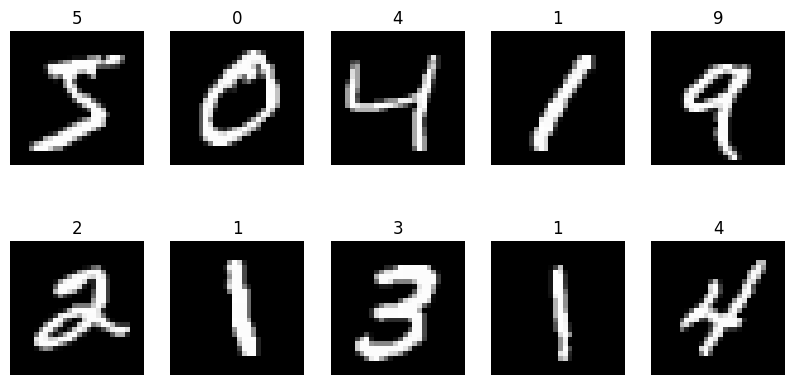

In [34]:
#Display Sample Images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [35]:
#Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [36]:
#Build Neural Network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
#Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9178 - loss: 0.2854 - val_accuracy: 0.9529 - val_loss: 0.1621
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9630 - loss: 0.1276 - val_accuracy: 0.9627 - val_loss: 0.1243
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9741 - loss: 0.0880 - val_accuracy: 0.9706 - val_loss: 0.1004
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9808 - loss: 0.0653 - val_accuracy: 0.9701 - val_loss: 0.1010
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9847 - loss: 0.0510 - val_accuracy: 0.9733 - val_loss: 0.0931
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9878 - loss: 0.0403 - val_accuracy: 0.9751 - val_loss: 0.0891
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9905 - loss: 0.0317 - val_accuracy: 0.9752 - val_loss: 0.0863
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9923 - loss: 0.0249 - 

In [39]:
#Evaluate Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy =", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.0820
Test Accuracy = 0.9764999747276306


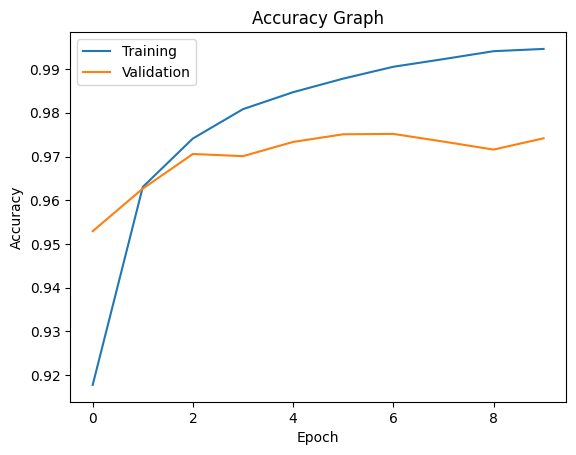

In [40]:
#Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Training','Validation'])
plt.show()

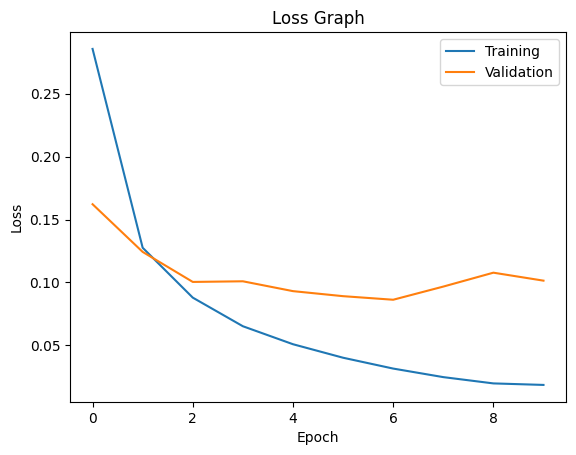

In [41]:
#Plot Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Training','Validation'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


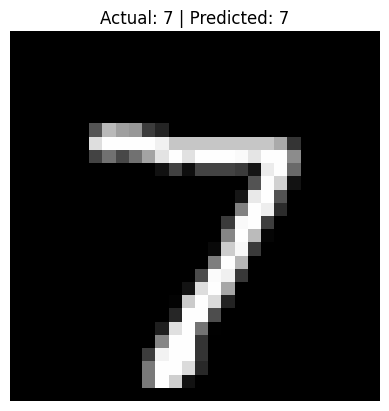

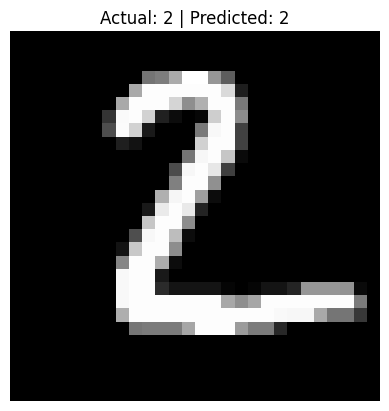

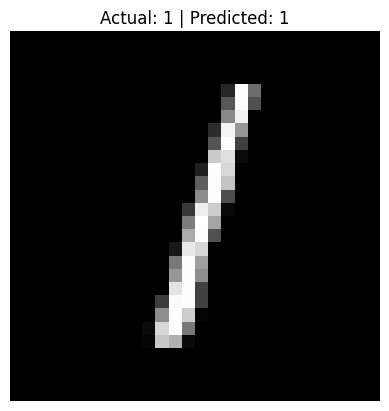

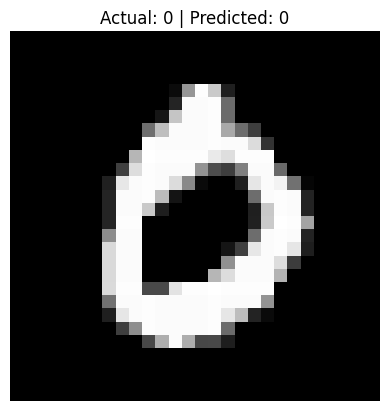

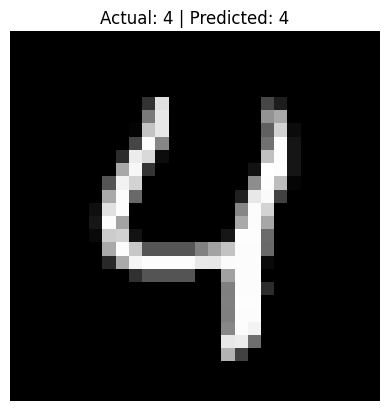

In [42]:
#Test on 5 Images
predictions = model.predict(X_test[:5])
for i in range(5):
    predicted_label = np.argmax(predictions[i])
    plt.imshow(X_test[i], cmap='gray')
    plt.title(
        f"Actual: {y_test[i]} | Predicted: {predicted_label}"
    )
    plt.axis('off')
    plt.show()


In [43]:
#Create Comparison Table
print("Actual\tPredicted")
for i in range(5):
    pred = np.argmax(predictions[i])
    print(y_test[i], "\t", pred)

Actual	Predicted
7 	 7
2 	 2
1 	 1
0 	 0
4 	 4


In [46]:
#Perform Experiment
#Add Dropout layer.
#Create a new model:
experiment_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

In [47]:
#Compile:
experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
#Train:
history2 = experiment_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8985 - loss: 0.3486 - val_accuracy: 0.9545 - val_loss: 0.1606
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9483 - loss: 0.1757 - val_accuracy: 0.9653 - val_loss: 0.1197
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9580 - loss: 0.1369 - val_accuracy: 0.9705 - val_loss: 0.1042
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9663 - loss: 0.1104 - val_accuracy: 0.9722 - val_loss: 0.0932
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9703 - loss: 0.0979 - val_accuracy: 0.9731 - val_loss: 0.0875
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9729 - loss: 0.0846 - val_accuracy: 0.9751 - val_loss: 0.0878
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9757 - loss: 0.0755 - val_accuracy: 0.9760 - val_loss: 0.0823
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9779 - loss: 0.0699 

In [49]:
#Evaluate:
loss2, acc2 = experiment_model.evaluate(X_test,y_test)
print("Experiment Accuracy =",acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9796 - loss: 0.0735
Experiment Accuracy = 0.9796000123023987


In [50]:
#Compare Results
print("Original Model Accuracy =", test_accuracy)
print("Experiment Model Accuracy =", acc2)

Original Model Accuracy = 0.9764999747276306
Experiment Model Accuracy = 0.9796000123023987
